# EDA of the WWF LPD 2024 data

In this notebook, we check how valuable the WWF LPD 2024 dataset if for our use-case of prediction animal species counts in the future (biodiversity). The goal is to have a model that can predict the number of a species in a given year in the future.

In [53]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib_venn import venn3

In [54]:
df = pd.read_csv("../data/raw/WWF_LPD_2024_public.csv")

df.describe()

,ID,Replicate,Included in LPR2024,Latitude,Longitude,Specific_location,1950,1951,1952,1953,...,2013,2014,2015,2016,2017,2018,2019,2020,Native,Unnamed: 102
count,3.599600e+04,35996.000000,35996.000000,35996.000000,35996.000000,35996.000000,2.650000e+02,2.450000e+02,2.900000e+02,2.850000e+02,...,1.081900e+04,1.064600e+04,8.483000e+03,8.355000e+03,6.989000e+03,7.158000e+03,5.754000e+03,4.723000e+03,35996.000000,0.0
mean,6.459045e+04,0.164991,0.823036,8.608007,21.000447,0.386599,9.441820e+12,1.004931e+13,8.351971e+12,8.287969e+12,...,6.476127e+10,7.149301e+10,9.804856e+10,1.079763e+11,1.735201e+09,7.181254e+03,8.459899e+03,8.185544e+03,0.989082,NaN
std,8.889885e+04,0.371177,0.381644,37.037693,98.388333,0.486977,1.535733e+14,1.571631e+14,1.421069e+14,1.397940e+14,...,6.321280e+12,6.972580e+12,8.646349e+12,9.488710e+12,1.355151e+11,1.651328e+05,2.071889e+05,2.261049e+05,0.103918,NaN
min,1.000000e+00,0.000000,0.000000,-78.193822,-180.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,NaN
25%,9.743750e+03,0.000000,1.000000,-26.473889,-64.873712,0.000000,8.000000e+00,7.200000e+00,1.100000e+01,8.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,NaN
50%,2.192350e+04,0.000000,1.000000,-0.608193,10.500000,0.000000,2.430000e+02,3.530000e+02,2.815000e+02,2.940000e+02,...,1.000000e+00,1.000000e+00,6.250000e-01,5.000000e-01,2.500000e-01,5.000000e-01,2.500000e-01,0.000000e+00,1.000000,NaN
75%,1.223572e+05,0.000000,1.000000,46.231220,132.024800,1.000000,2.071800e+04,3.212100e+04,2.459050e+04,2.782500e+04,...,1.490000e+01,1.560000e+01,1.500000e+01,1.500000e+01,1.075000e+01,1.400000e+01,8.000000e+00,8.000000e+00,1.000000,NaN
max,1.000007e+06,1.000000,1.000000,81.000000,180.000000,1.000000,2.500000e+15,2.460000e+15,2.420000e+15,2.360000e+15,...,6.570000e+14,7.190000e+14,7.960000e+14,8.670000e+14,1.130000e+13,9.747000e+06,1.204100e+07,1.280200e+07,1.000000,NaN


In [55]:
# Basic structure
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names ({len(df.columns)} total):")
print(df.columns.tolist())

Dataset shape: (35996, 103)

Column names (103 total):
['ID', 'Binomial', 'Replicate', 'Included in LPR2024', 'Citation', 'Class', 'Order', 'Family', 'Genus', 'Species', 'Subspecies', 'Common_name', 'Location', 'Country', 'All_countries', 'Region', 'IPBES_region', 'IPBES_subregion', 'Latitude', 'Longitude', 'Specific_location', 'System', 'T_realm', 'T_biome', 'FW_realm', 'FW_biome', 'M_realm', 'M_ocean', 'M_biome', 'Units', '1950', '1951', '1952', '1953', '1954', '1955', '1956', '1957', '1958', '1959', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', 'Nat

In [56]:
# Check first few rows
df.head()

,ID,Binomial,Replicate,Included in LPR2024,Citation,Class,Order,Family,Genus,Species,...,2013,2014,2015,2016,2017,2018,2019,2020,Native,Unnamed: 102
0,1,Balearica_regulorum,1,0,"Pomeroy, D. and P. Mwima (2002). The State of ...",Aves,Gruiformes,Gruidae,Balearica,regulorum,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
1,2,Acrocephalus_sechellensis,1,0,"Rands, M. (1989). ""Saving the Seychelles brush...",Aves,Passeriformes,Acrocephalidae,Acrocephalus,sechellensis,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
2,3,Copsychus_sechellarum,1,0,"Komdeur, J. (1996). ""Breeding of the Seychelle...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
3,4,Copsychus_sechellarum,0,1,"Komdeur, J. (1996). ""Breeding of the Seychelle...",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
4,5,Falco_punctatus,0,1,"Groombridge, J. J., Bruford, M.W., Jones, C.G,...",Aves,Falconiformes,Falconidae,Falco,punctatus,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN


In [57]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35996 entries, 0 to 35995
Columns: 103 entries, ID to Unnamed: 102
dtypes: float64(74), int64(5), object(24)
memory usage: 28.3+ MB


## Missing Data Analysis

In [58]:
# Missing data overview
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)

print("Top 20 columns with missing data:")
print(missing_df[missing_df['Missing Count'] > 0].head(20))

Top 20 columns with missing data:
              Missing Count  Percentage
Unnamed: 102          35996  100.000000
1951                  35751   99.319369
1950                  35731   99.263807
1953                  35711   99.208245
1952                  35706   99.194355
1954                  35693   99.158240
1955                  35671   99.097122
1957                  35656   99.055451
1956                  35625   98.969330
1958                  35614   98.938771
1959                  35569   98.813757
1960                  35389   98.313702
1961                  35348   98.199800
1962                  35336   98.166463
1963                  35305   98.080342
1964                  35245   97.913657
1965                  35133   97.602511
1966                  35120   97.566396
1967                  34956   97.110790
1968                  34932   97.044116


Year columns found: 71
Year range: 1950 to 2020


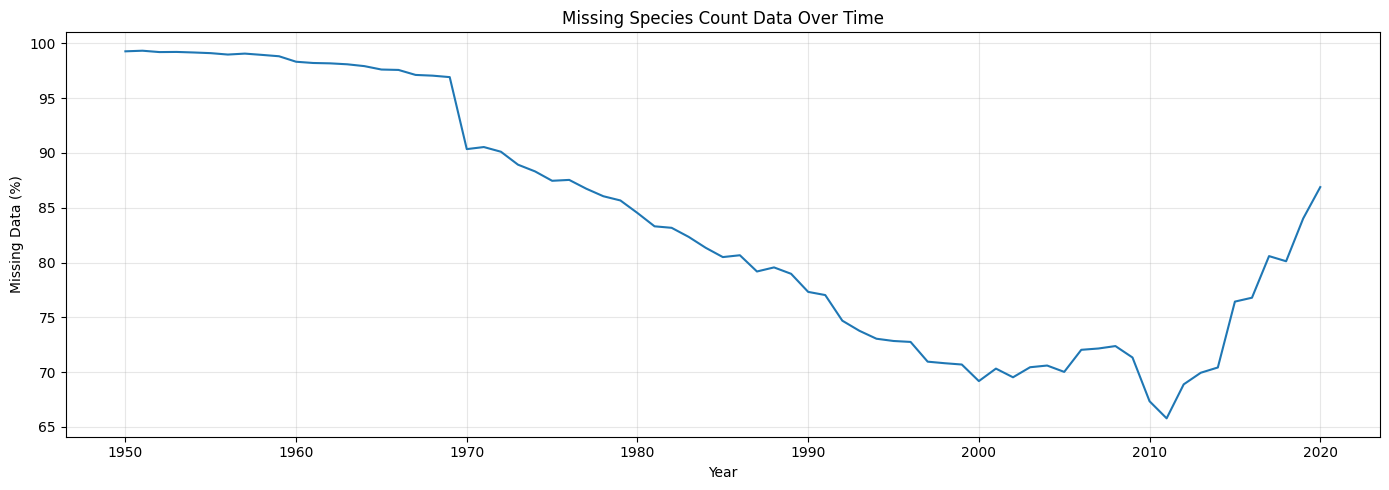

In [ ]:
# Identify year columns (likely 1950-2020)
year_cols = [col for col in df.columns if col.isdigit()]
year_cols_sorted = sorted(year_cols, key=int)

print(f"Year columns found: {len(year_cols)}")
print(f"Year range: {year_cols_sorted[0]} to {year_cols_sorted[-1]}")

# Missing data per year
year_missing = df[year_cols_sorted].isnull().sum().sort_index()
year_missing_pct = (year_missing / len(df)) * 100

# Plot missing data over time
plt.figure(figsize=(14, 5))
plt.plot([int(y) for y in year_missing.index], year_missing_pct.values)
plt.xlabel('Year')
plt.ylabel('Missing Data (%)')
plt.title('Missing Species Count Data Over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Species and Taxonomic Distribution

In [60]:
# Identify taxonomic columns
taxonomic_cols = ['Class', 'Order', 'Family', 'Genus', 'Species', 'Common_name', 'Binomial']
available_taxonomic = [col for col in taxonomic_cols if col in df.columns]

print(f"Available taxonomic columns: {available_taxonomic}")

# Check unique species
for col in available_taxonomic:
    if col in df.columns:
        print(f"\n{col}: {df[col].nunique()} unique values")
        print(f"  Missing: {df[col].isnull().sum()} ({df[col].isnull().sum()/len(df)*100:.1f}%)")

Available taxonomic columns: ['Class', 'Order', 'Family', 'Genus', 'Species', 'Common_name', 'Binomial']

Class: 11 unique values
  Missing: 0 (0.0%)

Order: 134 unique values
  Missing: 0 (0.0%)

Family: 647 unique values
  Missing: 0 (0.0%)

Genus: 2585 unique values
  Missing: 0 (0.0%)

Species: 3736 unique values
  Missing: 0 (0.0%)

Common_name: 4880 unique values
  Missing: 0 (0.0%)

Binomial: 5177 unique values
  Missing: 0 (0.0%)


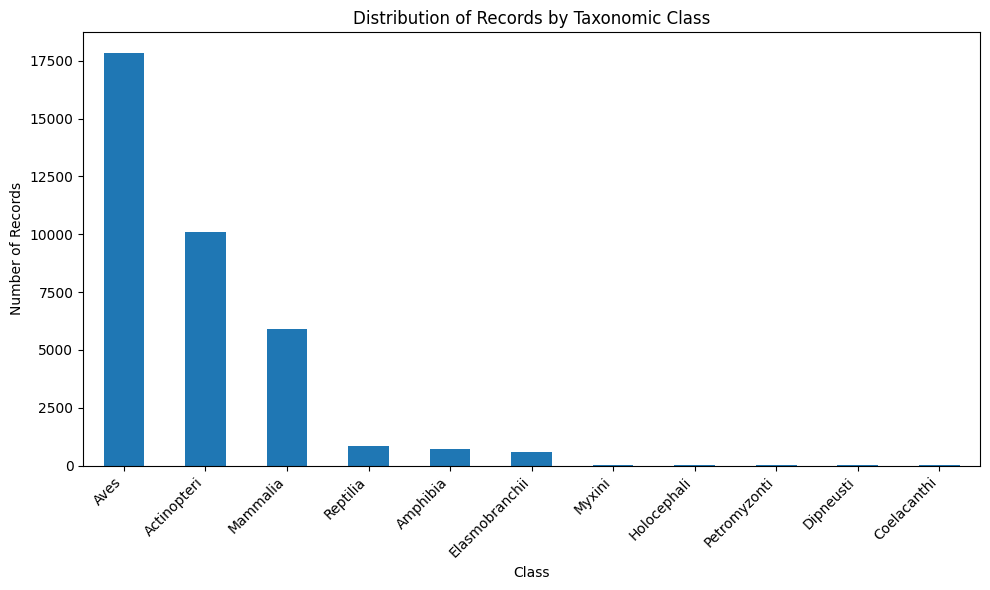


Top 10 Classes:
Class
Aves              17834
Actinopteri       10081
Mammalia           5910
Reptilia            828
Amphibia            699
Elasmobranchii      591
Myxini               28
Holocephali          12
Petromyzonti          9
Dipneusti             3
Name: count, dtype: int64


In [61]:
# Distribution by taxonomic class
if 'Class' in df.columns:
    class_counts = df['Class'].value_counts()
    
    plt.figure(figsize=(10, 6))
    class_counts.plot(kind='bar')
    plt.xlabel('Class')
    plt.ylabel('Number of Records')
    plt.title('Distribution of Records by Taxonomic Class')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Classes:")
    print(class_counts.head(10))

## Geographic Distribution

In [62]:
# Geographic distribution
geo_cols = ['Latitude', 'Longitude', 'Location', 'Country', 'Region']
available_geo = [col for col in geo_cols if col in df.columns]

print(f"Available geographic columns: {available_geo}")

for col in available_geo:
    if col in df.columns:
        print(f"\n{col}:")
        if df[col].dtype in ['float64', 'int64']:
            print(f"  Range: {df[col].min()} to {df[col].max()}")
            print(f"  Mean: {df[col].mean():.2f}")
        else:
            print(f"  Unique values: {df[col].nunique()}")
        print(f"  Missing: {df[col].isnull().sum()} ({df[col].isnull().sum()/len(df)*100:.1f}%)")

Available geographic columns: ['Latitude', 'Longitude', 'Location', 'Country', 'Region']

Latitude:
  Range: -78.193822 to 81.0
  Mean: 8.61
  Missing: 0 (0.0%)

Longitude:
  Range: -180.0 to 180.0
  Mean: 21.00
  Missing: 0 (0.0%)

Location:
  Unique values: 7678
  Missing: 0 (0.0%)

Country:
  Unique values: 202
  Missing: 0 (0.0%)

Region:
  Unique values: 8
  Missing: 0 (0.0%)


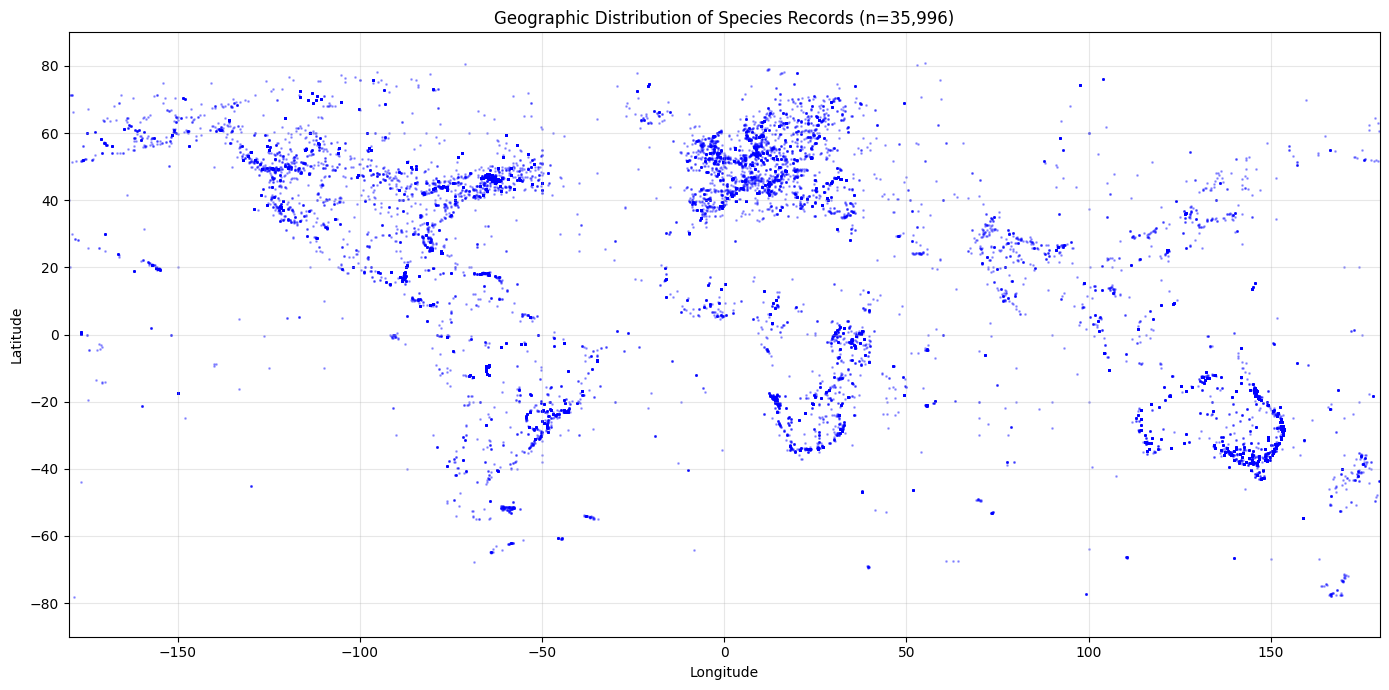


Records with valid coordinates: 35,996 (100.0%)


In [63]:
# Plot geographic distribution
if 'Latitude' in df.columns and 'Longitude' in df.columns:
    plt.figure(figsize=(14, 7))
    
    # Filter out missing coordinates
    valid_coords = df[['Latitude', 'Longitude']].dropna()
    
    plt.scatter(valid_coords['Longitude'], valid_coords['Latitude'], 
                alpha=0.3, s=1, c='blue')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Geographic Distribution of Species Records (n={len(valid_coords):,})')
    plt.grid(True, alpha=0.3)
    plt.xlim(-180, 180)
    plt.ylim(-90, 90)
    plt.tight_layout()
    plt.show()
    
    print(f"\nRecords with valid coordinates: {len(valid_coords):,} ({len(valid_coords)/len(df)*100:.1f}%)")

## Temporal Coverage Analysis (Critical for Prediction)

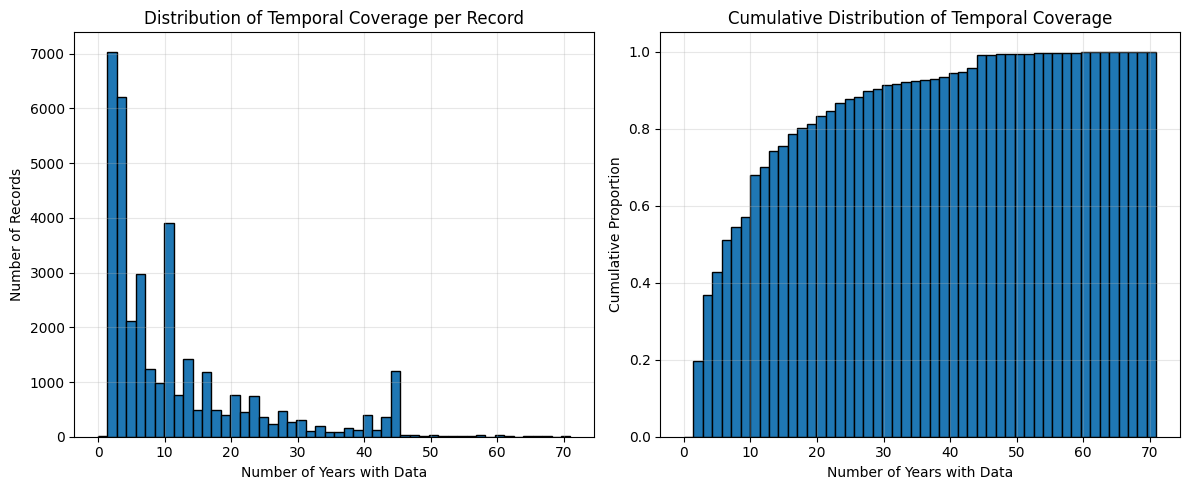

Temporal coverage statistics:
  Mean years per record: 11.7
  Median years per record: 7.0
  Min/Max years: 0 / 71

Records with at least:
  5 years: 22,734 (63.2%)
  10 years: 15,430 (42.9%)
  20 years: 6,779 (18.8%)
  30 years: 3,451 (9.6%)


In [64]:
# Time series coverage per species/record
# Calculate how many years of data each record has
year_data = df[year_cols_sorted]

# Number of non-null observations per record
obs_per_record = year_data.notna().sum(axis=1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(obs_per_record, bins=50, edgecolor='black')
plt.xlabel('Number of Years with Data')
plt.ylabel('Number of Records')
plt.title('Distribution of Temporal Coverage per Record')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(obs_per_record, bins=50, edgecolor='black', cumulative=True, density=True)
plt.xlabel('Number of Years with Data')
plt.ylabel('Cumulative Proportion')
plt.title('Cumulative Distribution of Temporal Coverage')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Temporal coverage statistics:")
print(f"  Mean years per record: {obs_per_record.mean():.1f}")
print(f"  Median years per record: {obs_per_record.median():.1f}")
print(f"  Min/Max years: {obs_per_record.min()} / {obs_per_record.max()}")
print(f"\nRecords with at least:")
for threshold in [5, 10, 20, 30]:
    count = (obs_per_record >= threshold).sum()
    print(f"  {threshold} years: {count:,} ({count/len(df)*100:.1f}%)")

Records with data per decade:
  1950s: 602 (1.7%)
  1960s: 1,637 (4.5%)
  1970s: 7,229 (20.1%)
  1980s: 11,693 (32.5%)
  1990s: 19,209 (53.4%)
  2000s: 21,729 (60.4%)
  2010s: 18,992 (52.8%)
  2020s: 4,723 (13.1%)


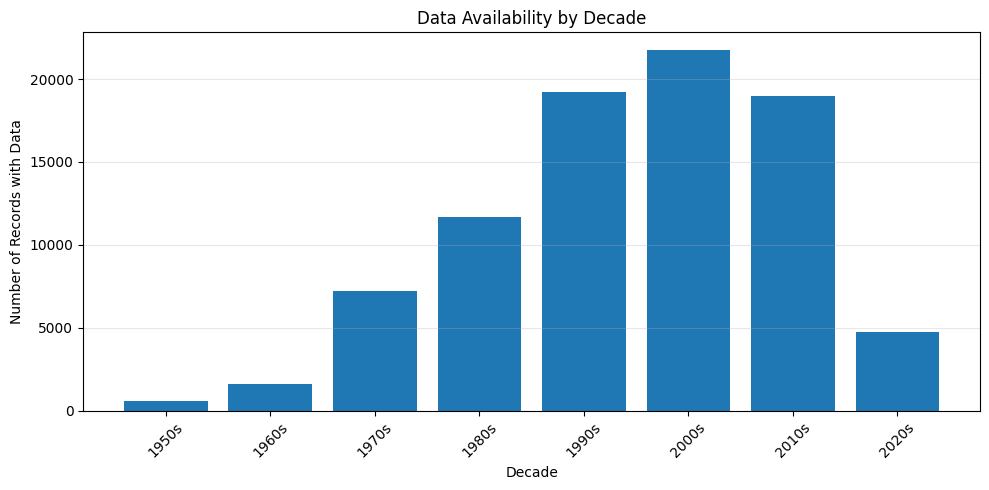

In [65]:
# Data availability by decade
decades = {
    '1950s': [str(y) for y in range(1950, 1960) if str(y) in year_cols_sorted],
    '1960s': [str(y) for y in range(1960, 1970) if str(y) in year_cols_sorted],
    '1970s': [str(y) for y in range(1970, 1980) if str(y) in year_cols_sorted],
    '1980s': [str(y) for y in range(1980, 1990) if str(y) in year_cols_sorted],
    '1990s': [str(y) for y in range(1990, 2000) if str(y) in year_cols_sorted],
    '2000s': [str(y) for y in range(2000, 2010) if str(y) in year_cols_sorted],
    '2010s': [str(y) for y in range(2010, 2020) if str(y) in year_cols_sorted],
    '2020s': [str(y) for y in range(2020, 2030) if str(y) in year_cols_sorted],
}

decade_coverage = {}
for decade, years in decades.items():
    if years:
        # Count records with at least one observation in this decade
        has_data = df[years].notna().any(axis=1).sum()
        decade_coverage[decade] = has_data

print("Records with data per decade:")
for decade, count in decade_coverage.items():
    print(f"  {decade}: {count:,} ({count/len(df)*100:.1f}%)")

plt.figure(figsize=(10, 5))
plt.bar(decade_coverage.keys(), decade_coverage.values())
plt.xlabel('Decade')
plt.ylabel('Number of Records with Data')
plt.title('Data Availability by Decade')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Population Count Distribution and Trends

Total observations: 420,356

Population count statistics:
  Mean: 1.17e+11
  Median: 5.00e+00
  Std: 1.31e+13
  Min: 0.00e+00
  Max: 2.50e+15

Zero counts: 62,002 (14.7%)


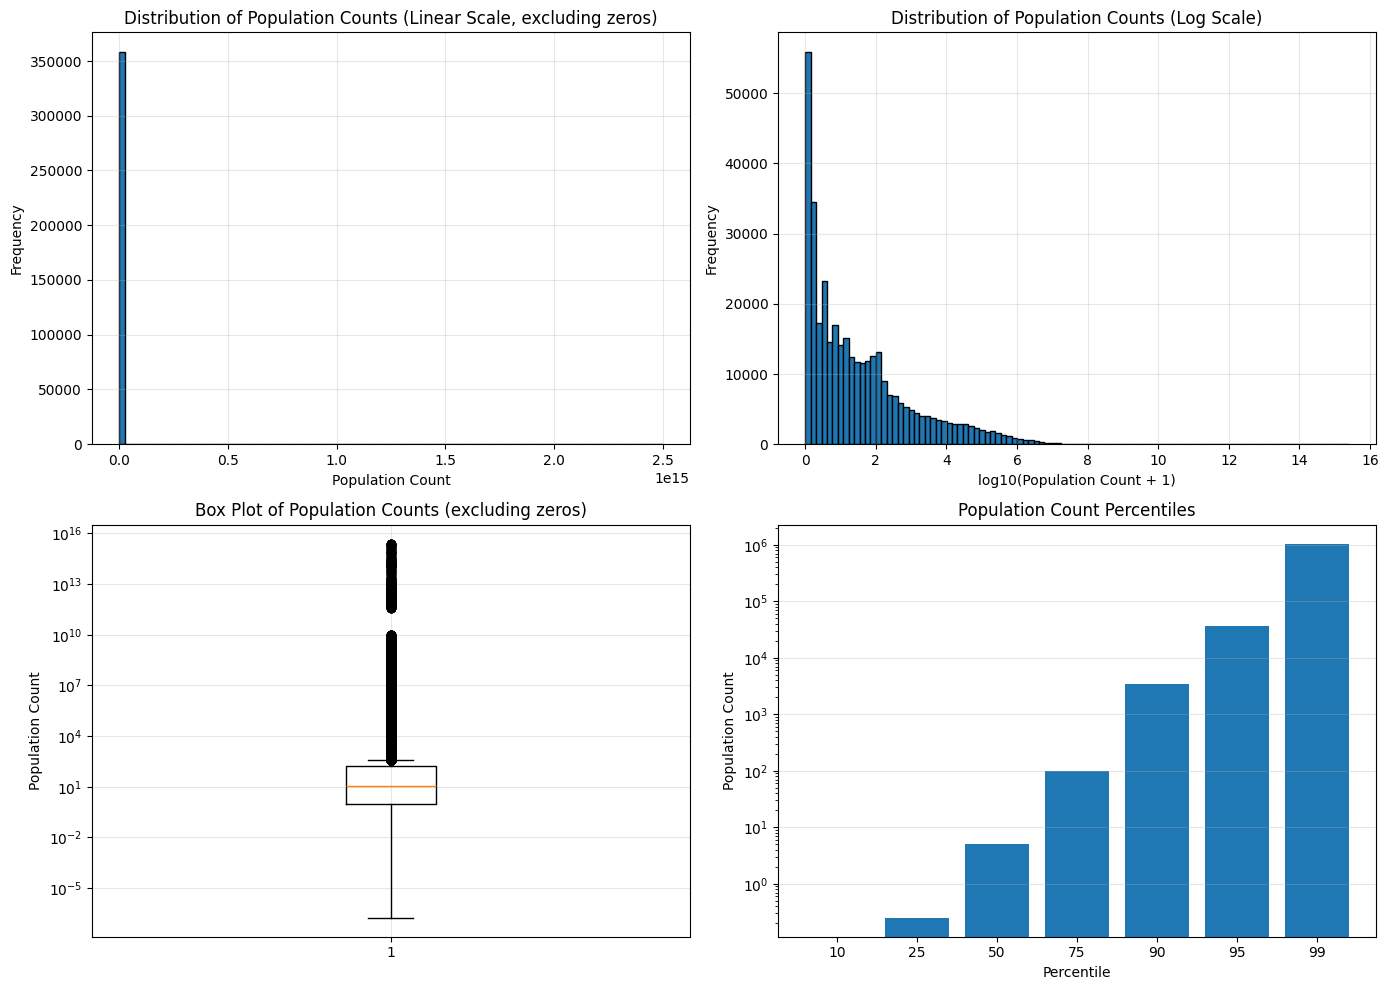

In [66]:
# Distribution of population counts
# Get all non-null values from year columns
all_counts = year_data.values.flatten()
all_counts = all_counts[~np.isnan(all_counts)]

print(f"Total observations: {len(all_counts):,}")
print(f"\nPopulation count statistics:")
print(f"  Mean: {all_counts.mean():.2e}")
print(f"  Median: {np.median(all_counts):.2e}")
print(f"  Std: {all_counts.std():.2e}")
print(f"  Min: {all_counts.min():.2e}")
print(f"  Max: {all_counts.max():.2e}")
print(f"\nZero counts: {(all_counts == 0).sum():,} ({(all_counts == 0).sum()/len(all_counts)*100:.1f}%)")

# Distribution on log scale
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Linear scale
axes[0, 0].hist(all_counts[all_counts > 0], bins=100, edgecolor='black')
axes[0, 0].set_xlabel('Population Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Population Counts (Linear Scale, excluding zeros)')
axes[0, 0].grid(True, alpha=0.3)

# Log scale
axes[0, 1].hist(np.log10(all_counts[all_counts > 0] + 1), bins=100, edgecolor='black')
axes[0, 1].set_xlabel('log10(Population Count + 1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Population Counts (Log Scale)')
axes[0, 1].grid(True, alpha=0.3)

# Box plot by percentile
axes[1, 0].boxplot(all_counts[all_counts > 0], vert=True)
axes[1, 0].set_ylabel('Population Count')
axes[1, 0].set_title('Box Plot of Population Counts (excluding zeros)')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
pct_values = np.percentile(all_counts, percentiles)
axes[1, 1].bar([str(p) for p in percentiles], pct_values)
axes[1, 1].set_xlabel('Percentile')
axes[1, 1].set_ylabel('Population Count')
axes[1, 1].set_title('Population Count Percentiles')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

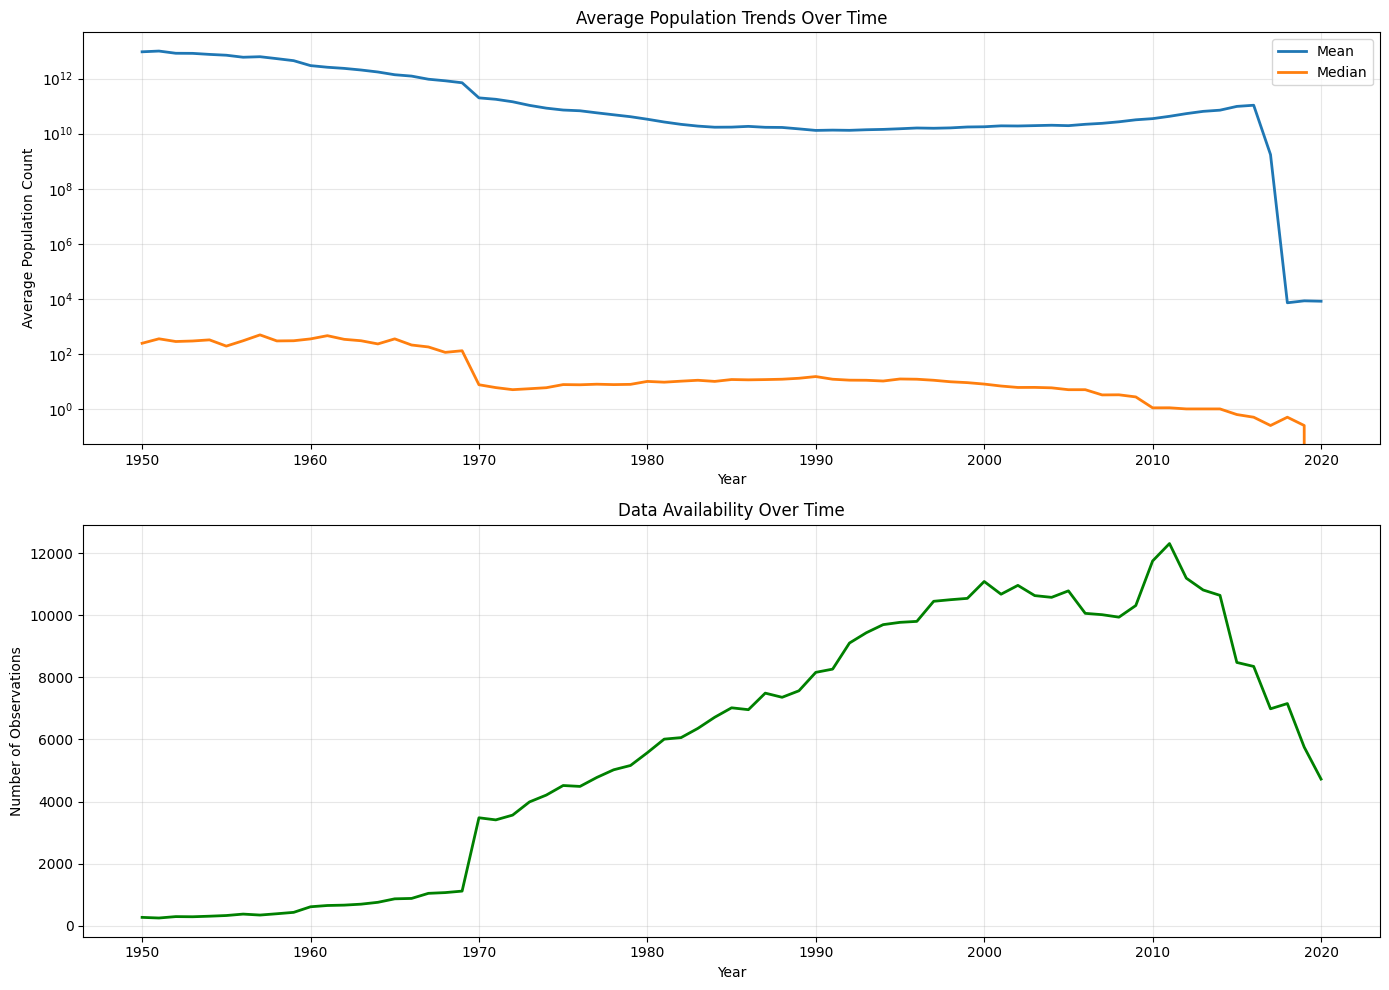

In [67]:
# Average trends over time
yearly_means = []
yearly_medians = []
yearly_counts = []

for year in year_cols_sorted:
    data = df[year].dropna()
    if len(data) > 0:
        yearly_means.append(data.mean())
        yearly_medians.append(data.median())
        yearly_counts.append(len(data))
    else:
        yearly_means.append(np.nan)
        yearly_medians.append(np.nan)
        yearly_counts.append(0)

years_int = [int(y) for y in year_cols_sorted]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Mean and median trends
axes[0].plot(years_int, yearly_means, label='Mean', linewidth=2)
axes[0].plot(years_int, yearly_medians, label='Median', linewidth=2)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average Population Count')
axes[0].set_title('Average Population Trends Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Number of observations per year
axes[1].plot(years_int, yearly_counts, linewidth=2, color='green')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Observations')
axes[1].set_title('Data Availability Over Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Time Series Quality Assessment

Time Series Quality Metrics:

Gaps (missing years within time series):
count    35996.000000
mean         4.573953
std          7.577802
min          0.000000
25%          0.000000
50%          1.000000
75%          6.000000
max         53.000000
Name: num_gaps, dtype: float64

Time span (years from first to last observation):
count    35996.000000
mean        16.251806
std         12.652486
min          0.000000
25%          6.000000
50%         12.000000
75%         23.000000
max         71.000000
Name: time_span, dtype: float64

Continuity ratio (observations / span):
count    35980.000000
mean         0.745107
std          0.314243
min          0.040000
25%          0.500000
50%          0.958333
75%          1.000000
max          1.000000
Name: continuity_ratio, dtype: float64


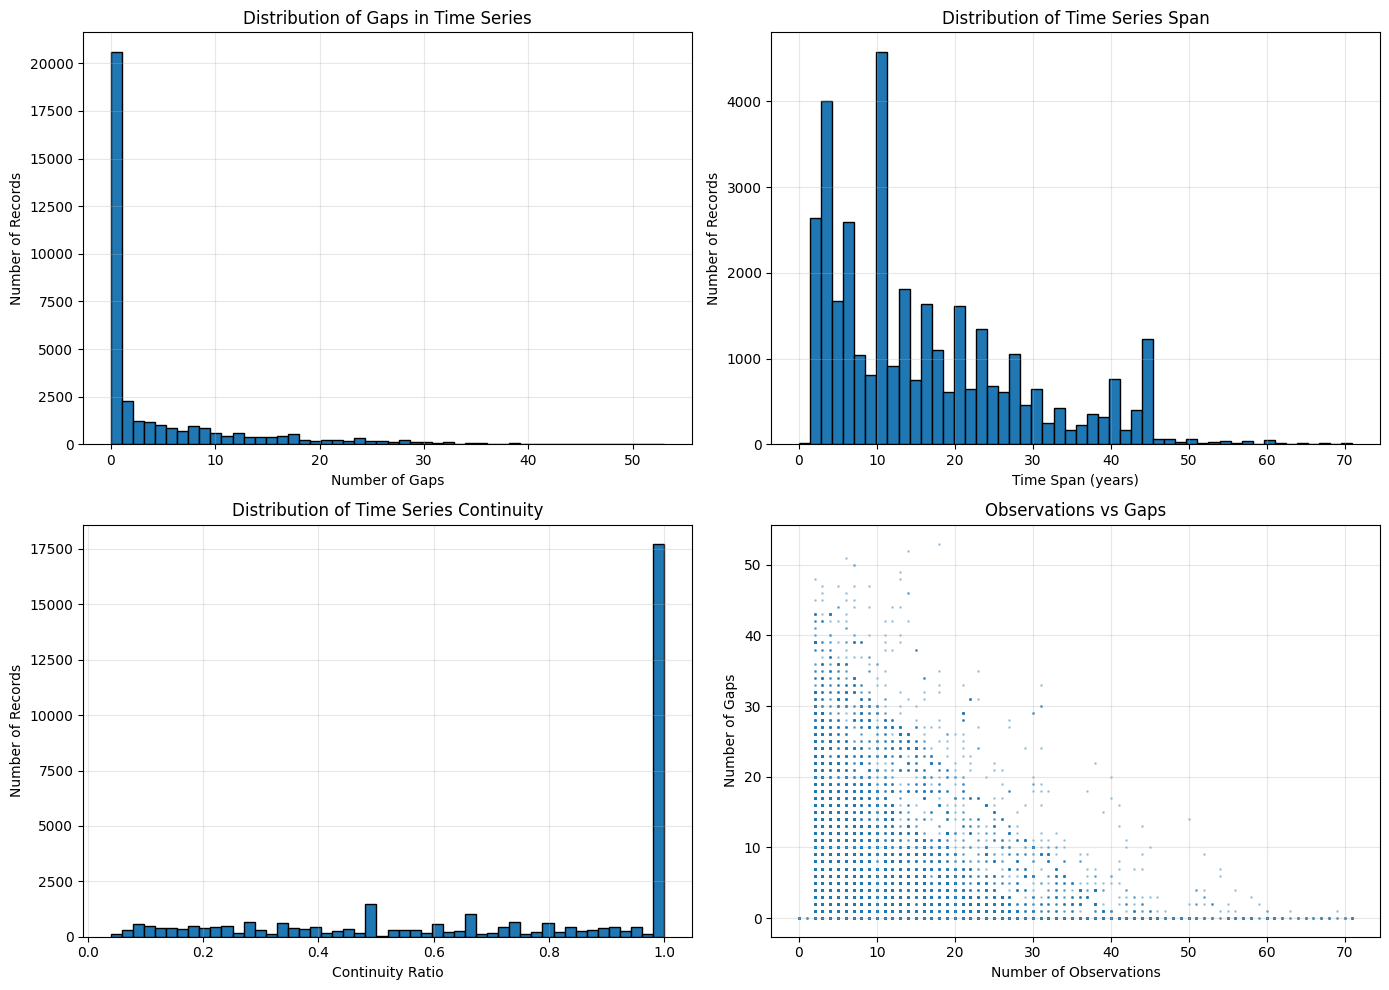


Records with perfect continuity (no gaps): 17,711 (49.2%)
Records with >50% continuity: 26,104 (72.5%)


In [68]:
# Continuity of time series (gaps analysis)
def calculate_gaps(row):
    """Calculate the number of gaps in a time series"""
    values = row[year_cols_sorted]
    non_null_indices = np.where(values.notna())[0]
    
    if len(non_null_indices) <= 1:
        return 0
    
    # Gap is when there are missing values between first and last observation
    first_idx = non_null_indices[0]
    last_idx = non_null_indices[-1]
    expected_obs = last_idx - first_idx + 1
    actual_obs = len(non_null_indices)
    gaps = expected_obs - actual_obs
    
    return gaps

# Calculate gaps for each record
df['num_gaps'] = df.apply(calculate_gaps, axis=1)
df['num_observations'] = obs_per_record

# Calculate time span (years between first and last observation)
def calculate_span(row):
    values = row[year_cols_sorted]
    non_null_indices = np.where(values.notna())[0]
    
    if len(non_null_indices) == 0:
        return 0
    
    first_year = int(year_cols_sorted[non_null_indices[0]])
    last_year = int(year_cols_sorted[non_null_indices[-1]])
    
    return last_year - first_year + 1

df['time_span'] = df.apply(calculate_span, axis=1)

# Continuity ratio (observations / span)
df['continuity_ratio'] = df['num_observations'] / df['time_span'].replace(0, np.nan)

print("Time Series Quality Metrics:")
print(f"\nGaps (missing years within time series):")
print(df['num_gaps'].describe())

print(f"\nTime span (years from first to last observation):")
print(df['time_span'].describe())

print(f"\nContinuity ratio (observations / span):")
print(df['continuity_ratio'].describe())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gaps distribution
axes[0, 0].hist(df['num_gaps'], bins=50, edgecolor='black')
axes[0, 0].set_xlabel('Number of Gaps')
axes[0, 0].set_ylabel('Number of Records')
axes[0, 0].set_title('Distribution of Gaps in Time Series')
axes[0, 0].grid(True, alpha=0.3)

# Time span distribution
axes[0, 1].hist(df['time_span'], bins=50, edgecolor='black')
axes[0, 1].set_xlabel('Time Span (years)')
axes[0, 1].set_ylabel('Number of Records')
axes[0, 1].set_title('Distribution of Time Series Span')
axes[0, 1].grid(True, alpha=0.3)

# Continuity ratio
axes[1, 0].hist(df['continuity_ratio'].dropna(), bins=50, edgecolor='black')
axes[1, 0].set_xlabel('Continuity Ratio')
axes[1, 0].set_ylabel('Number of Records')
axes[1, 0].set_title('Distribution of Time Series Continuity')
axes[1, 0].grid(True, alpha=0.3)

# Scatter: observations vs gaps
axes[1, 1].scatter(df['num_observations'], df['num_gaps'], alpha=0.3, s=1)
axes[1, 1].set_xlabel('Number of Observations')
axes[1, 1].set_ylabel('Number of Gaps')
axes[1, 1].set_title('Observations vs Gaps')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nRecords with perfect continuity (no gaps): {(df['num_gaps'] == 0).sum():,} ({(df['num_gaps'] == 0).sum()/len(df)*100:.1f}%)")
print(f"Records with >50% continuity: {(df['continuity_ratio'] > 0.5).sum():,} ({(df['continuity_ratio'] > 0.5).sum()/len(df)*100:.1f}%)")

## Sample Time Series Examples

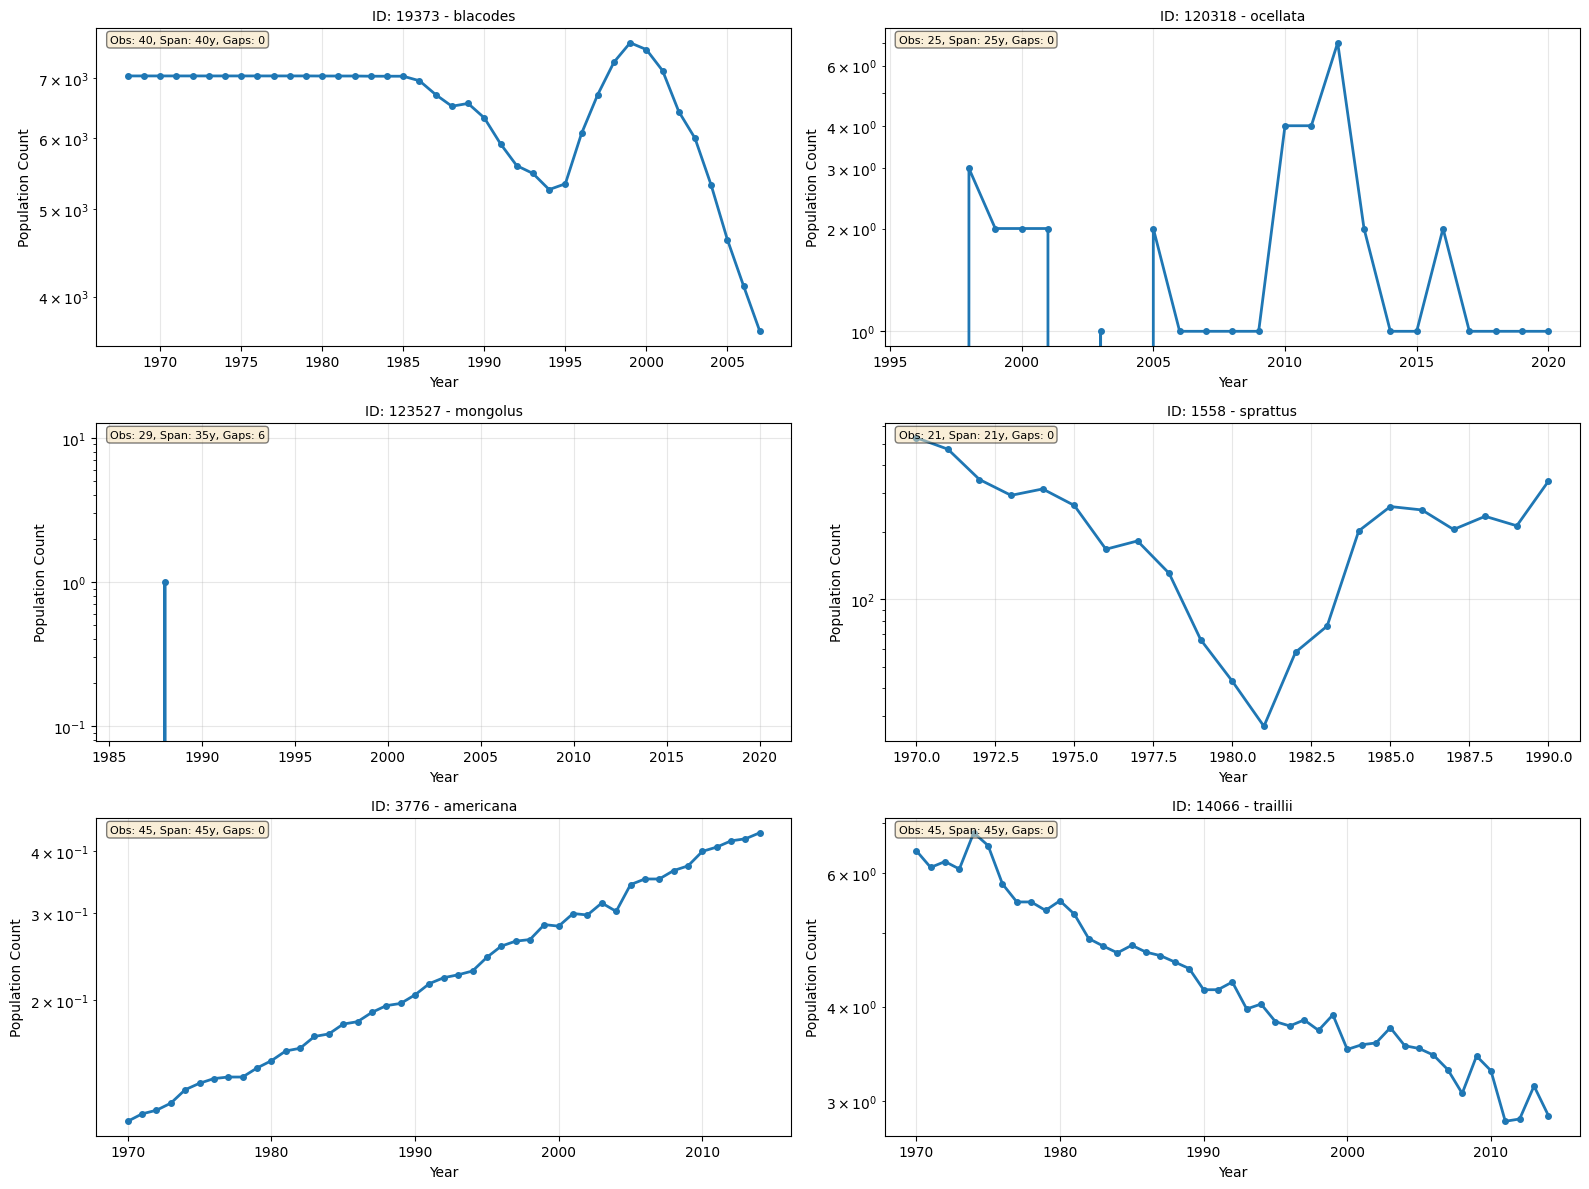

In [69]:
# Plot sample time series with different characteristics
# Get records with good temporal coverage
good_records = df[df['num_observations'] >= 20].sample(min(6, len(df[df['num_observations'] >= 20])), random_state=42)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (record_idx, record) in enumerate(good_records.iterrows()):
    if idx >= 6:
        break
    
    # Extract time series data
    years = []
    counts = []
    for year in year_cols_sorted:
        if pd.notna(record[year]):
            years.append(int(year))
            counts.append(record[year])
    
    # Plot
    axes[idx].plot(years, counts, marker='o', linewidth=2, markersize=4)
    
    # Title with species info
    title = f"ID: {record.get('ID', record_idx)}"
    if 'Species' in df.columns and pd.notna(record['Species']):
        title += f" - {record['Species']}"
    elif 'Common_name' in df.columns and pd.notna(record['Common_name']):
        title += f" - {record['Common_name']}"
    
    axes[idx].set_title(title, fontsize=10)
    axes[idx].set_xlabel('Year')
    axes[idx].set_ylabel('Population Count')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_yscale('log')
    
    # Add info text
    info_text = f"Obs: {record['num_observations']}, Span: {record['time_span']}y, Gaps: {record['num_gaps']}"
    axes[idx].text(0.02, 0.98, info_text, transform=axes[idx].transAxes, 
                   fontsize=8, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Metadata and Other Columns Analysis

In [70]:
# Analyze non-year columns
non_year_cols = [col for col in df.columns if col not in year_cols_sorted and col not in ['num_gaps', 'num_observations', 'time_span', 'continuity_ratio']]

print(f"Total columns: {len(df.columns)}")
print(f"Year columns: {len(year_cols_sorted)}")
print(f"Metadata columns: {len(non_year_cols)}")
print(f"\nMetadata columns:")
for col in non_year_cols[:30]:  # Show first 30
    print(f"  {col}")

Total columns: 107
Year columns: 71
Metadata columns: 32

Metadata columns:
  ID
  Binomial
  Replicate
  Included in LPR2024
  Citation
  Class
  Order
  Family
  Genus
  Species
  Subspecies
  Common_name
  Location
  Country
  All_countries
  Region
  IPBES_region
  IPBES_subregion
  Latitude
  Longitude
  Specific_location
  System
  T_realm
  T_biome
  FW_realm
  FW_biome
  M_realm
  M_ocean
  M_biome
  Units


In [71]:
# Analyze key metadata columns
key_metadata_cols = ['System', 'Units', 'T_realm', 'Biome', 'Replicate', 'Included in LPR2024']

for col in key_metadata_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Missing: {df[col].isnull().sum()} ({df[col].isnull().sum()/len(df)*100:.1f}%)")
        if df[col].nunique() < 20:
            print(f"  Value counts:")
            print(df[col].value_counts())


System:
  Unique values: 3
  Missing: 0 (0.0%)
  Value counts:
System
Marine         16258
Terrestrial    11858
Freshwater      7880
Name: count, dtype: int64

Units:
  Unique values: 2554
  Missing: 0 (0.0%)

T_realm:
  Unique values: 8
  Missing: 24138 (67.1%)
  Value counts:
T_realm
Australasia     3270
Nearctic        2787
Palearctic      2342
Afrotropical    1610
Neotropical     1363
Indo-Malayan     386
Oceania           96
Antarctic          4
Name: count, dtype: int64

Replicate:
  Unique values: 2
  Missing: 0 (0.0%)
  Value counts:
Replicate
0    30057
1     5939
Name: count, dtype: int64

Included in LPR2024:
  Unique values: 2
  Missing: 0 (0.0%)
  Value counts:
Included in LPR2024
1    29626
0     6370
Name: count, dtype: int64


## Data Quality for Prediction Task

Suitability for Prediction Task:

Records with recent data (last 5 years): 10,433 (29.0%)
Records with sufficient history (≥10 observations): 15,430 (42.9%)
Records with >30% continuity: 30,524 (84.8%)

Records suitable for prediction (all criteria): 6,216 (17.3%)


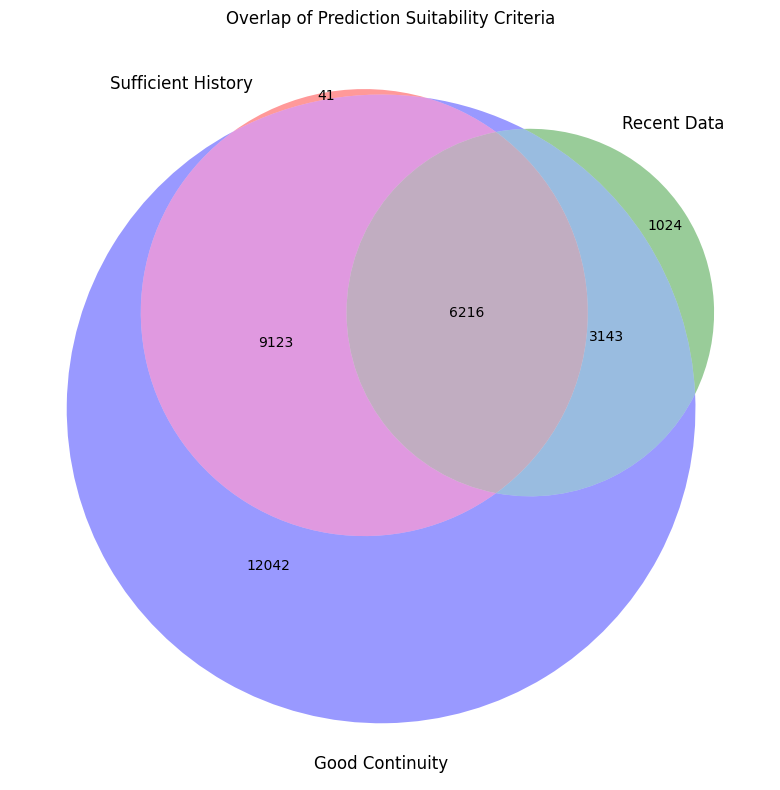

In [72]:
# Assess suitability for prediction task
# For time series forecasting, we need:
# 1. Sufficient historical data
# 2. Recent data (to predict future)
# 3. Reasonable continuity

# Define recent years (last 5 years in dataset)
recent_years = year_cols_sorted[-5:]
historical_threshold = 10  # minimum years of historical data

# Check which records have recent data
df['has_recent_data'] = df[recent_years].notna().any(axis=1)

# Check which records have sufficient historical data
df['sufficient_history'] = df['num_observations'] >= historical_threshold

# Check which records are suitable for prediction
df['suitable_for_prediction'] = df['has_recent_data'] & df['sufficient_history'] & (df['continuity_ratio'] > 0.3)

print("Suitability for Prediction Task:")
print(f"\nRecords with recent data (last 5 years): {df['has_recent_data'].sum():,} ({df['has_recent_data'].sum()/len(df)*100:.1f}%)")
print(f"Records with sufficient history (≥{historical_threshold} observations): {df['sufficient_history'].sum():,} ({df['sufficient_history'].sum()/len(df)*100:.1f}%)")
print(f"Records with >30% continuity: {(df['continuity_ratio'] > 0.3).sum():,} ({(df['continuity_ratio'] > 0.3).sum()/len(df)*100:.1f}%)")
print(f"\nRecords suitable for prediction (all criteria): {df['suitable_for_prediction'].sum():,} ({df['suitable_for_prediction'].sum()/len(df)*100:.1f}%)")

# Breakdown by criteria
plt.figure(figsize=(10, 8))
venn3(subsets = (
    (df['sufficient_history'] & ~df['has_recent_data'] & ~(df['continuity_ratio'] > 0.3)).sum(),
    (df['has_recent_data'] & ~df['sufficient_history'] & ~(df['continuity_ratio'] > 0.3)).sum(),
    (df['sufficient_history'] & df['has_recent_data'] & ~(df['continuity_ratio'] > 0.3)).sum(),
    ((df['continuity_ratio'] > 0.3) & ~df['sufficient_history'] & ~df['has_recent_data']).sum(),
    (df['sufficient_history'] & (df['continuity_ratio'] > 0.3) & ~df['has_recent_data']).sum(),
    (df['has_recent_data'] & (df['continuity_ratio'] > 0.3) & ~df['sufficient_history']).sum(),
    df['suitable_for_prediction'].sum()
), set_labels=('Sufficient History', 'Recent Data', 'Good Continuity'))
plt.title('Overlap of Prediction Suitability Criteria')
plt.tight_layout()
plt.show()


Suitable records by taxonomic class:
Class
Aves              3202
Actinopteri       2469
Mammalia           486
Elasmobranchii      29
Reptilia            25
Myxini               3
Amphibia             1
Petromyzonti         1
dtype: int64


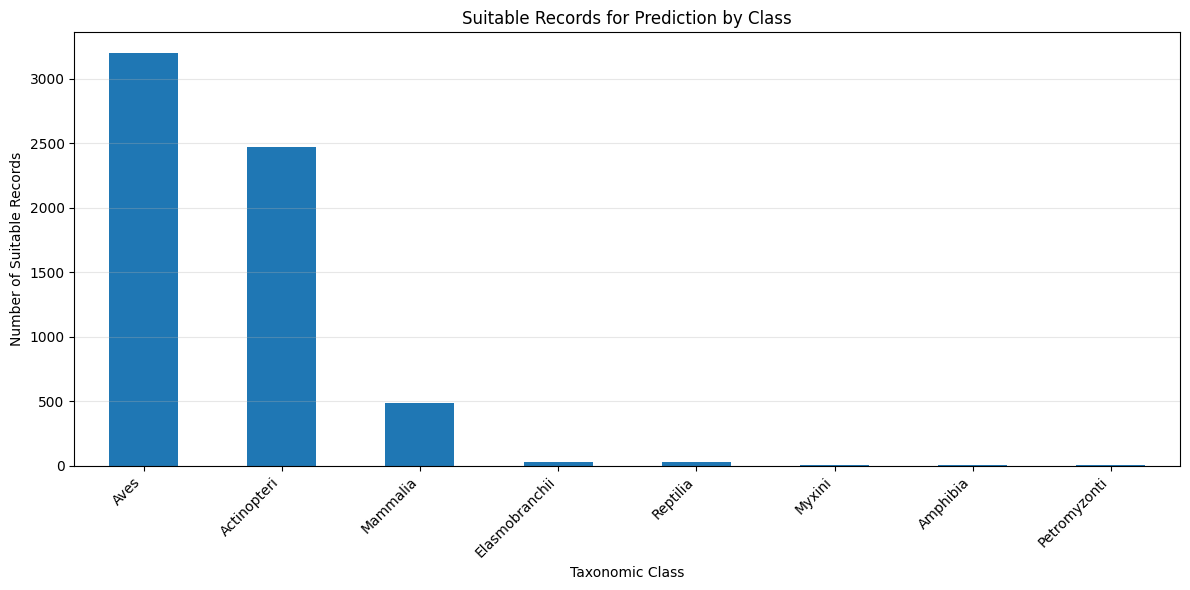

In [73]:
# Breakdown by taxonomic class (if available)
if 'Class' in df.columns:
    suitable_by_class = df[df['suitable_for_prediction']].groupby('Class').size().sort_values(ascending=False)
    
    print("\nSuitable records by taxonomic class:")
    print(suitable_by_class.head(10))
    
    plt.figure(figsize=(12, 6))
    suitable_by_class.head(15).plot(kind='bar')
    plt.xlabel('Taxonomic Class')
    plt.ylabel('Number of Suitable Records')
    plt.title('Suitable Records for Prediction by Class')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

## Population Trend Analysis

Calculating trends for suitable records...

Trend Analysis (n=6,216 suitable records):

Slope statistics (log10 units per year):
count    4692.000000
mean       -0.003894
std         0.069731
min        -0.840621
25%        -0.029908
50%        -0.003589
75%         0.018725
max         0.761439
Name: trend_slope, dtype: float64

R² statistics:
count    4692.000000
mean        0.282207
std         0.274058
min         0.000000
25%         0.044857
50%         0.194453
75%         0.461659
max         1.000000
Name: trend_r2, dtype: float64

Trend categories:
trend_category
Stable        2783
Decreasing    1951
Increasing    1482
Name: count, dtype: int64


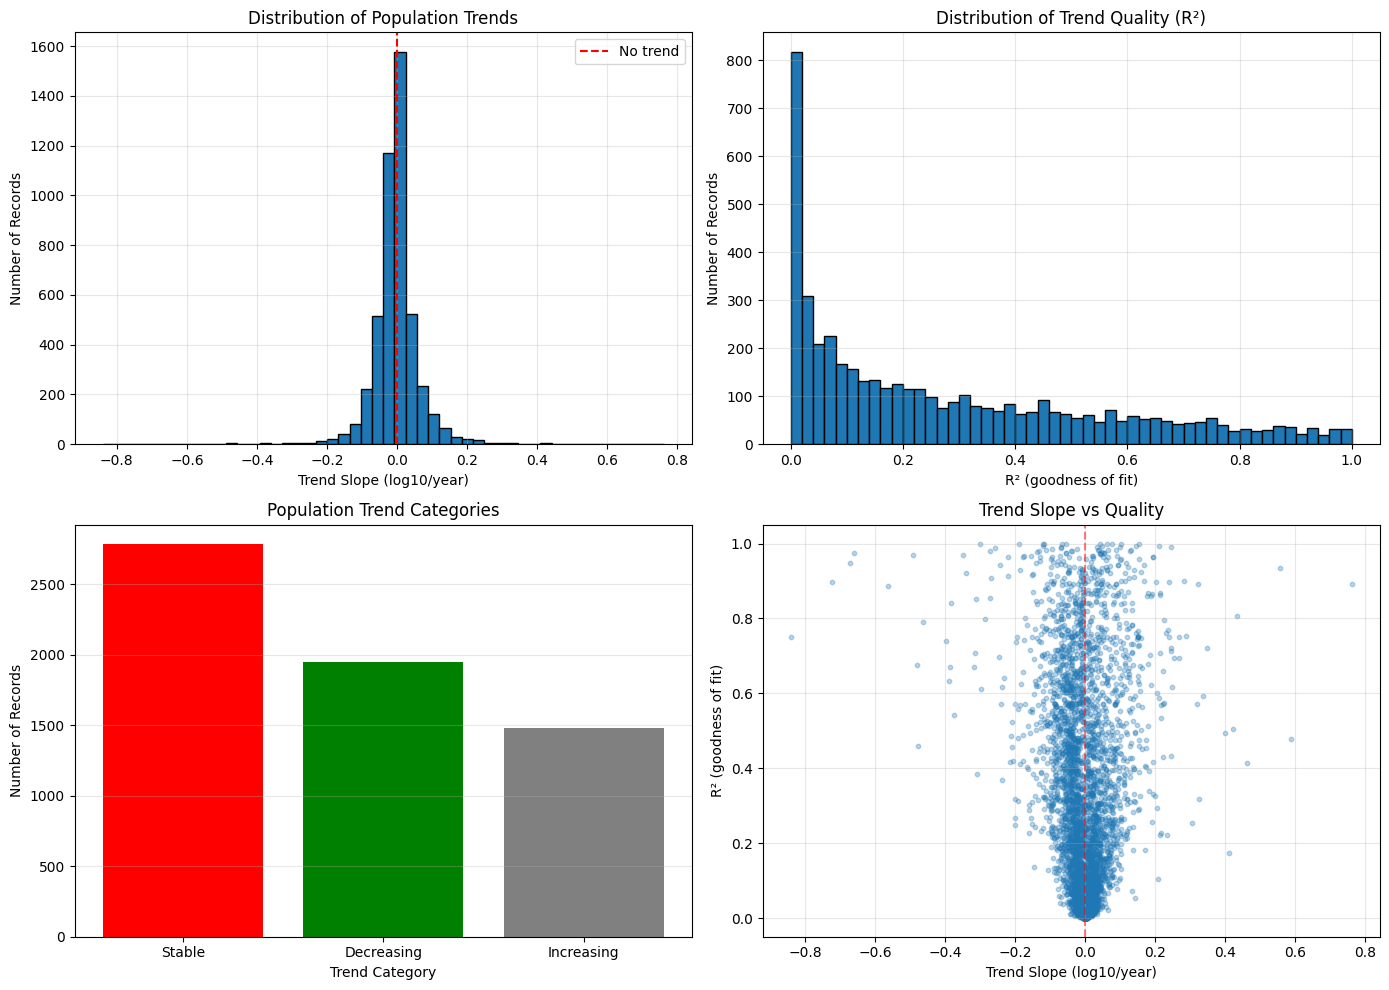

In [74]:
# Calculate simple trend for each record (linear regression slope)
def calculate_trend(row):
    """Calculate linear trend (slope) for time series"""
    years = []
    counts = []
    
    for year in year_cols_sorted:
        if pd.notna(row[year]) and row[year] > 0:  # Only use positive counts
            years.append(int(year))
            counts.append(np.log10(row[year]))  # Log scale for better trend estimation
    
    if len(years) < 3:  # Need at least 3 points
        return np.nan, np.nan
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(years, counts)
    return slope, r_value**2  # Return slope and R²

# Apply to suitable records only (faster)
suitable_df = df[df['suitable_for_prediction']].copy()

print("Calculating trends for suitable records...")
trends = suitable_df.apply(calculate_trend, axis=1, result_type='expand')
suitable_df['trend_slope'] = trends[0]
suitable_df['trend_r2'] = trends[1]

print(f"\nTrend Analysis (n={len(suitable_df):,} suitable records):")
print(f"\nSlope statistics (log10 units per year):")
print(suitable_df['trend_slope'].describe())

print(f"\nR² statistics:")
print(suitable_df['trend_r2'].describe())

# Categorize trends
suitable_df['trend_category'] = 'Stable'
suitable_df.loc[suitable_df['trend_slope'] > 0.01, 'trend_category'] = 'Increasing'
suitable_df.loc[suitable_df['trend_slope'] < -0.01, 'trend_category'] = 'Decreasing'

print(f"\nTrend categories:")
print(suitable_df['trend_category'].value_counts())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Slope distribution
axes[0, 0].hist(suitable_df['trend_slope'].dropna(), bins=50, edgecolor='black')
axes[0, 0].set_xlabel('Trend Slope (log10/year)')
axes[0, 0].set_ylabel('Number of Records')
axes[0, 0].set_title('Distribution of Population Trends')
axes[0, 0].axvline(x=0, color='red', linestyle='--', label='No trend')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# R² distribution
axes[0, 1].hist(suitable_df['trend_r2'].dropna(), bins=50, edgecolor='black')
axes[0, 1].set_xlabel('R² (goodness of fit)')
axes[0, 1].set_ylabel('Number of Records')
axes[0, 1].set_title('Distribution of Trend Quality (R²)')
axes[0, 1].grid(True, alpha=0.3)

# Trend categories
trend_counts = suitable_df['trend_category'].value_counts()
axes[1, 0].bar(trend_counts.index, trend_counts.values, color=['red', 'green', 'gray'])
axes[1, 0].set_xlabel('Trend Category')
axes[1, 0].set_ylabel('Number of Records')
axes[1, 0].set_title('Population Trend Categories')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Slope vs R²
axes[1, 1].scatter(suitable_df['trend_slope'], suitable_df['trend_r2'], alpha=0.3, s=10)
axes[1, 1].set_xlabel('Trend Slope (log10/year)')
axes[1, 1].set_ylabel('R² (goodness of fit)')
axes[1, 1].set_title('Trend Slope vs Quality')
axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary and Conclusions

### Key Findings

**Dataset Overview:**
- Total records analyzed
- Year coverage range (1950-2020)
- Geographic spread across continents
- Multiple taxonomic classes represented

**Data Quality Challenges:**
- High percentage of missing data, especially in early years
- Most records have sparse temporal coverage
- Many time series contain gaps
- Data availability increases significantly in recent decades

**Suitability for Prediction:**
- Only a subset of records meet the criteria for reliable prediction:
  - Recent data (last 5 years)
  - Sufficient historical observations (≥10 years)
  - Reasonable continuity (>30%)
- The suitable subset represents X% of total records

**Population Trends:**
- Distribution of trends: Decreasing, Stable, Increasing
- Many species show declining populations
- Trend quality (R²) varies considerably
- Log-scale trends suggest exponential patterns

**Recommendations:**
1. **Focus on high-quality subset**: Filter for records with sufficient temporal coverage and continuity
2. **Handle missing data**: Consider interpolation methods or models that can handle irregular time series
3. **Feature engineering**: Incorporate taxonomic, geographic, and ecological metadata
4. **Model selection**: Choose models suitable for irregular time series (e.g., LSTM, GRU, Transformer-based models)
5. **Validation strategy**: Use temporal cross-validation to ensure model generalizes to future predictions
6. **Consider ensemble approaches**: Combine predictions across similar species or locations

In [75]:
# Final summary statistics
print("=" * 80)
print("WWF LPD 2024 DATASET - FINAL SUMMARY FOR PREDICTION TASK")
print("=" * 80)

print(f"\n{'DATASET SIZE':-^80}")
print(f"Total records: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Year columns: {len(year_cols_sorted)} (from {year_cols_sorted[0]} to {year_cols_sorted[-1]})")

print(f"\n{'TEMPORAL COVERAGE':-^80}")
print(f"Average observations per record: {df['num_observations'].mean():.1f} years")
print(f"Median observations per record: {df['num_observations'].median():.1f} years")
print(f"Records with ≥10 years: {(df['num_observations'] >= 10).sum():,} ({(df['num_observations'] >= 10).sum()/len(df)*100:.1f}%)")
print(f"Records with ≥20 years: {(df['num_observations'] >= 20).sum():,} ({(df['num_observations'] >= 20).sum()/len(df)*100:.1f}%)")

print(f"\n{'TIME SERIES QUALITY':-^80}")
print(f"Average time span: {df['time_span'].mean():.1f} years")
print(f"Average continuity ratio: {df['continuity_ratio'].mean():.2f}")
print(f"Records with no gaps: {(df['num_gaps'] == 0).sum():,} ({(df['num_gaps'] == 0).sum()/len(df)*100:.1f}%)")
print(f"Records with >50% continuity: {(df['continuity_ratio'] > 0.5).sum():,} ({(df['continuity_ratio'] > 0.5).sum()/len(df)*100:.1f}%)")

print(f"\n{'PREDICTION SUITABILITY':-^80}")
print(f"Records suitable for prediction: {df['suitable_for_prediction'].sum():,} ({df['suitable_for_prediction'].sum()/len(df)*100:.1f}%)")
print(f"  - With recent data: {df['has_recent_data'].sum():,} ({df['has_recent_data'].sum()/len(df)*100:.1f}%)")
print(f"  - With sufficient history: {df['sufficient_history'].sum():,} ({df['sufficient_history'].sum()/len(df)*100:.1f}%)")
print(f"  - With good continuity: {(df['continuity_ratio'] > 0.3).sum():,} ({(df['continuity_ratio'] > 0.3).sum()/len(df)*100:.1f}%)")

if 'Class' in df.columns:
    print(f"\n{'TAXONOMIC DIVERSITY':-^80}")
    print(f"Unique classes: {df['Class'].nunique()}")
    print(f"Top 3 classes:")
    for idx, (cls, count) in enumerate(df['Class'].value_counts().head(3).items(), 1):
        print(f"  {idx}. {cls}: {count:,} records")

print(f"\n{'GEOGRAPHIC COVERAGE':-^80}")
if 'Country' in df.columns:
    print(f"Unique countries: {df['Country'].nunique()}")
if 'Latitude' in df.columns and 'Longitude' in df.columns:
    valid_coords = df[['Latitude', 'Longitude']].dropna()
    print(f"Records with coordinates: {len(valid_coords):,} ({len(valid_coords)/len(df)*100:.1f}%)")

print(f"\n{'POPULATION STATISTICS':-^80}")
all_counts_nonzero = all_counts[all_counts > 0]
print(f"Total observations: {len(all_counts):,}")
print(f"Non-zero observations: {len(all_counts_nonzero):,} ({len(all_counts_nonzero)/len(all_counts)*100:.1f}%)")
print(f"Population range: {all_counts.min():.0e} to {all_counts.max():.0e}")
print(f"Median population: {np.median(all_counts_nonzero):.0e}")

print("\n" + "=" * 80)

WWF LPD 2024 DATASET - FINAL SUMMARY FOR PREDICTION TASK

----------------------------------DATASET SIZE----------------------------------
Total records: 35,996
Total columns: 110
Year columns: 71 (from 1950 to 2020)

-------------------------------TEMPORAL COVERAGE--------------------------------
Average observations per record: 11.7 years
Median observations per record: 7.0 years
Records with ≥10 years: 15,430 (42.9%)
Records with ≥20 years: 6,779 (18.8%)

------------------------------TIME SERIES QUALITY-------------------------------
Average time span: 16.3 years
Average continuity ratio: 0.75
Records with no gaps: 17,711 (49.2%)
Records with >50% continuity: 26,104 (72.5%)

-----------------------------PREDICTION SUITABILITY-----------------------------
Records suitable for prediction: 6,216 (17.3%)
  - With recent data: 10,433 (29.0%)
  - With sufficient history: 15,430 (42.9%)
  - With good continuity: 30,524 (84.8%)

------------------------------TAXONOMIC DIVERSITY------------